In [28]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from sydr.io.database import DatabaseHandler
from sydr.utils.constants import GPS_L1CA_CODE_SIZE_BITS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Retrieve data from database

In [29]:
filepaths = {
    'Exact' : '/mnt/d/Projects/Navigation/MyCode/sydr/.results/_save/40MHz_AxC/1KV6/REC_GPS_L1CA.db',
    '1KXF' : '/mnt/d/Projects/Navigation/MyCode/sydr/.results/_save/40MHz_AxC/1KXF/REC_GPS_L1CA.db',
    '1L12' : '/mnt/d/Projects/Navigation/MyCode/sydr/.results/_save/40MHz_AxC/1L12/REC_GPS_L1CA.db'
}

In [30]:
receivers = {}
for name, path in filepaths.items():
    receivers[name] = {
        'name'     : name,
        'database' : DatabaseHandler(path , overwrite=False)
    }

In [31]:
receivers['1L12']

{'name': '1L12',
 'database': <sydr.io.database.DatabaseHandler at 0x7fbb82859310>}

In [32]:
channelList = receivers['1L12']['database'].fetchTable('channel')
df = pd.DataFrame(channelList)
df

,id,physical_id,system,satellite_id,signal,start_time,stop_time,start_sample
0,0,None,GPS,2,GPS_L1_CA,1.724925e+09,None,0
1,1,None,GPS,3,GPS_L1_CA,1.724925e+09,None,0
2,2,None,GPS,17,GPS_L1_CA,1.724925e+09,None,0
3,3,None,GPS,21,GPS_L1_CA,1.724925e+09,None,0
4,4,None,GPS,32,GPS_L1_CA,1.724925e+09,None,0


In [96]:
prn = df[4]['satellite_id']

KeyError: 4

In [90]:
channel_id = 4
prn = df[4]['satellite_id']

for name, _ in receivers.items():
    receivers[name]['acquisition'] = 
    receivers[name]['acquisition'] = receivers[name]['database'].fetchAcquisition(channel_id)[0]


In [91]:
COLORS = {
    'Exact' : '#033F63',
    '1KXF'  : '#58BC82',
    '1L12'  : '#EE7B30'
}

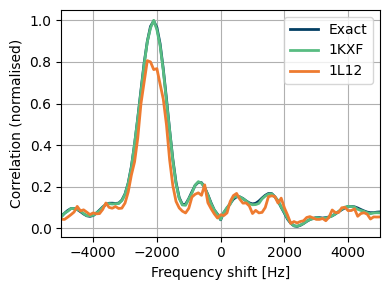

In [92]:
doppler_range = 5000
doppler_steps = 100
frequencyBins = np.arange(-doppler_range, doppler_range+1, doppler_steps)

max_value = 0
for name, receiver in receivers.items():
    new_max = np.max(receiver['acquisition']["correlation_map"])
    if new_max > max_value:
        max_value = new_max

plt.figure(figsize=(4,3))
for name, receiver in receivers.items():
    plt.plot(
        frequencyBins, 
        receiver['acquisition']["correlation_map"][:, receiver['acquisition']["code_idx"]]/max_value,
        label=name,
        color=COLORS[name],
        linewidth=2)

plt.grid()
plt.ylabel("Correlation (normalised)")
plt.xlabel("Frequency shift [Hz]")
plt.xlim((-doppler_range, doppler_range))
plt.legend()
plt.tight_layout()
plt.savefig("axc_sydr_freq_G02.png", dpi=300)

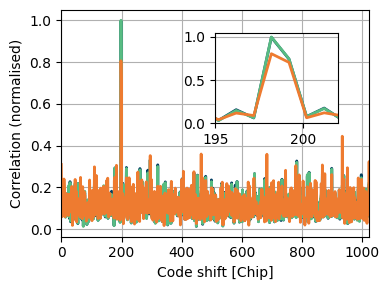

In [95]:
codeBins = np.linspace(0, GPS_L1CA_CODE_SIZE_BITS, np.size(receivers['Exact']['acquisition']["correlation_map"], axis=1))

fig, ax = plt.subplots(figsize=(4,3))
x1, x2, y1, y2 = 195, 202, 0.0, 1.05  # subregion of the original image
axins = ax.inset_axes(
    [0.5, 0.5, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2))

for name, receiver in receivers.items():
    ax.plot(
        codeBins, 
        receiver['acquisition']["correlation_map"][receiver['acquisition']["frequency_idx"], :]/max_value,
        label=name,
        color=COLORS[name],
        linewidth=2)

    axins.plot(
        codeBins, 
        receiver['acquisition']["correlation_map"][receiver['acquisition']["frequency_idx"], :]/max_value,
        label=name,
        color=COLORS[name],
        linewidth=2)

#plt.xlim((340, 360))

axins.grid()
#[axins.annotate(re.sub('mul\d+s_', '', txt), (df[kpi_x][i], df[kpi_y][i]+2e-3)) for i, txt in enumerate(df['NAME'])]
#ax.indicate_inset_zoom(axins, edgecolor="black")

plt.grid()
plt.ylabel("Correlation (normalised)")
plt.xlabel("Code shift [Chip]")
plt.xlim((0, 1022))
#plt.legend()
plt.tight_layout()
plt.savefig("axc_sydr_code_G02.png", dpi=300)

In [94]:
channel_id = 1

for name, _ in receivers.items():
    receivers[name]['tracking'] = receivers[name]['database'].fetchTracking(channel_id)